In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import ttest_ind
from glob import glob
import os

# Set style for plotting
sns.set(style="whitegrid")

# Search and load relevant CSV files
csv_paths = glob("MRTFA_measurement_merged.csv")
pdf = PdfPages("MRTFA.pdf")

df_list = []
for path in csv_paths:
    df = pd.read_csv(path)
    df_list.append(df)

# Concatenate all dataframes into one
all_data = pd.concat(df_list, ignore_index=True)

# Function to remove outliers based on IQR
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 * IQR)]


#cell area, pixel^2 to um^2, subject to change imaging parameters
all_data["Cell_Area"] = all_data["Cell_Area"]*0.32251517949029
all_data["nucleous_Area"] = all_data["nucleous_Area"]*0.32251517949029


plot_pairs = [
    ("Condition", "Cell_Area"),
    ("Condition", "nucleous_Area"),
    ("Condition", "Phalloidin_Mean_Intensity"),
    ("Condition", "Phalloidin_Total_Intensity"),
    ("Condition", "TF_Mean_Intensity"),
    ("Condition", "TF_Total_Intensity"),
    ("Condition", "TF_nuclear_mean"),
    # ("Condition", "TF_nuclear_total"),
    # ("Condition", "TF_nc_ratio_mean"),
    ("Condition", "TF_nc_ratio_total"),
]

# Plot with lowess smoothing

condition_order = ["Ctrl", "MVG0.75", "MVG1.25"]

norm_data = all_data
# normalziation by Ctrl, rep
value_cols = [
    'Phalloidin_Mean_Intensity', 'TF_Mean_Intensity',
    'Phalloidin_Total_Intensity', 'TF_Total_Intensity',
    'TF_nuclear_mean','TF_nc_ratio_total'
]

all_data['Rep_index'] = 1
norm_data = all_data.copy()

for rep in all_data['Rep_index'].unique():
    ctrl_subset = all_data[(all_data['Rep_index'] == rep) & (all_data['Condition'] == 'Ctrl')]
    ctrl_means = ctrl_subset[value_cols].mean()

    rep_mask = all_data['Rep_index'] == rep
    norm_data.loc[rep_mask, value_cols] = all_data.loc[rep_mask, value_cols] / ctrl_means


/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


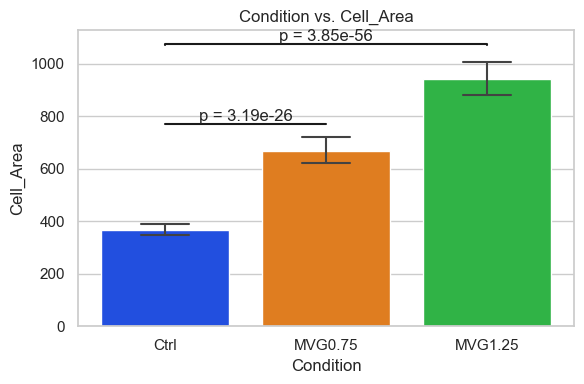

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


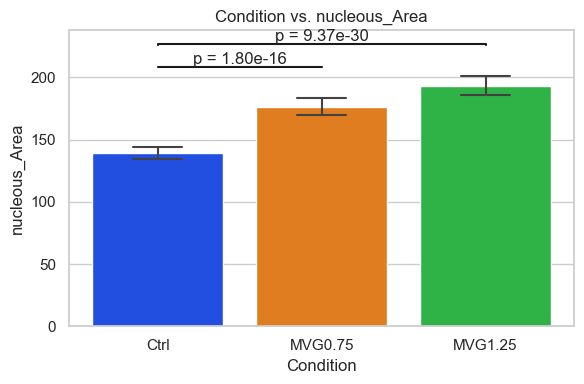

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


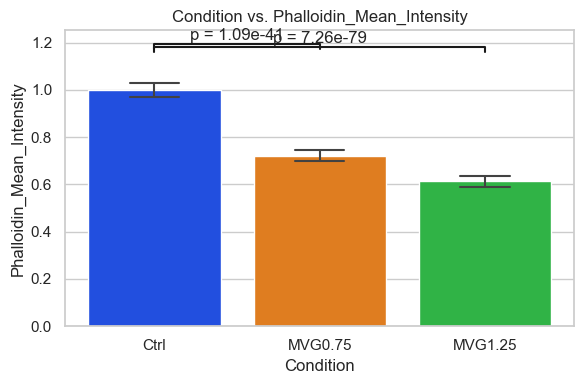

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


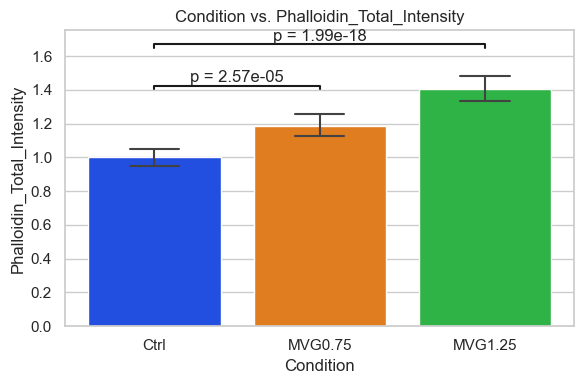

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


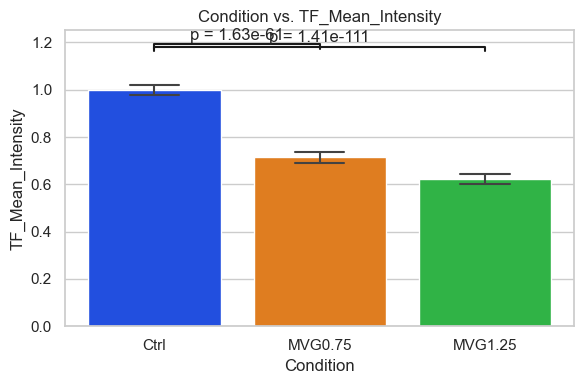

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


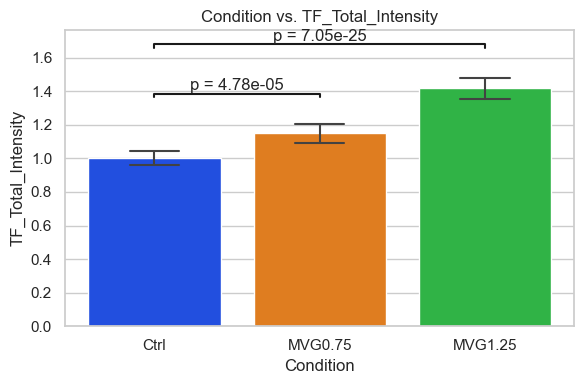

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


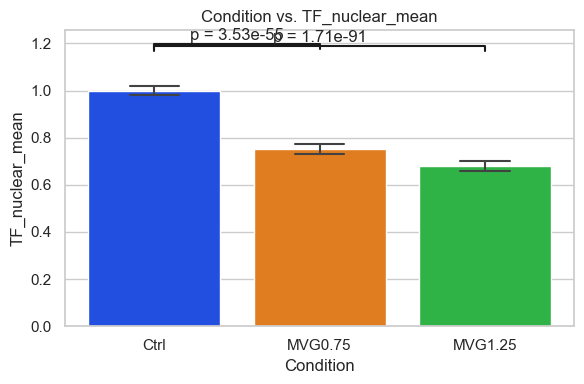

/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)
/var/folders/zm/29fkf2bd64j15vvv5kcm80th0000gn/T/ipykernel_87287/914020928.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)


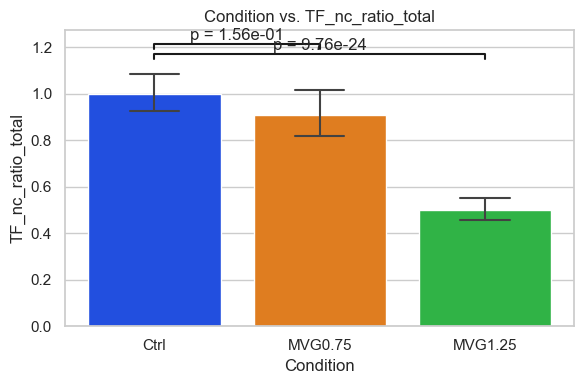

In [36]:
for x, y in plot_pairs:
    # 데이터 추출
    ctrl1 = norm_data[norm_data[x] == "Ctrl"][y].dropna()
    # ctrl2 = norm_data[norm_data[x] == "Ctrlanta"][y].dropna()
    mvg1 = norm_data[norm_data[x] == "MVG0.75"][y].dropna()
    mvg2 = norm_data[norm_data[x] == "MVG1.25"][y].dropna()

    # p-value 계산
    p_ctrl = ttest_ind(ctrl1, mvg1, equal_var=False).pvalue
    p_mvg = ttest_ind(ctrl1, mvg2, equal_var=False).pvalue

    # 그래프 그리기
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(data=norm_data, x=x, y=y, palette="bright", order=condition_order, capsize=0.3, errwidth=1.5)

    # 각 막대의 높이 추출
    bar_heights = [patch.get_height() for patch in ax.patches]

    # Ctrl 비교선
    x1, x2 = 0, 1
    y1, y2 = bar_heights[x1], bar_heights[x2]
    y_ctrl = max(y1, y2) + 0.1 * (y1 + y2)  # 막대 상단보다 살짝 위
    ax.plot([x1, x1, x2, x2], [y_ctrl, y_ctrl + 0.02, y_ctrl + 0.02, y_ctrl], lw=1.5, c='k')
    ax.text((x1 + x2) / 2, y_ctrl + 0.025, f"p = {p_ctrl:.2e}", ha='center', va='bottom')

    # MVG 비교선
    x3, x4 = 0, 2
    y3, y4 = bar_heights[x3], bar_heights[x4]
    y_mvg = max(y3, y4) + 0.1 * (y3 + y4)
    ax.plot([x3, x3, x4, x4], [y_mvg, y_mvg + 0.02, y_mvg + 0.02, y_mvg], lw=1.5, c='k')
    ax.text((x3 + x4) / 2, y_mvg + 0.025, f"p = {p_mvg:.2e}", ha='center', va='bottom')

    plt.title(f"{x} vs. {y}")
    plt.xlabel("Condition")
    plt.ylabel(y)
    plt.tight_layout()
    pdf.savefig()
    plt.show()
    plt.close()


pdf.close()

In [ ]:
base_folder = "processed"
# MVG_data = norm_data[norm_data["Condition"].isin(["MVG","MVGagon"])]
csv_path = os.path.join(base_folder, f'MRTFA_final.csv')
norm_data.to_csv(csv_path, index=False)